# Post-5B Measurement Audit A — Direction and Response Onset

This executed reporting notebook reads the saved Metrica Sample Game 1 audit artifacts. It does not fit a predictive model, inspect Game 3, select opponents, define an onset threshold, or classify tactical responses.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
OUT=ROOT/'outputs'/'post5b_measurement_audit_a'
FIG=ROOT/'figures'/'post5b_measurement_audit_a'
summary=pd.read_csv(OUT/'window_summary.csv')
assessment=json.loads((OUT/'audit_assessment.json').read_text())
qc=json.loads((OUT/'qc_results.json').read_text())
assert qc['passed'] and not qc['metrica_game3_accessed']
assessment

{'classification': 'B',
 'label': 'MIXED',
 'formal_validation_justified_now': False,
 'supported_claim': 'Directional focal-relative displacement preserves geometric distinctions that scalar focal-relative path magnitude collapses, but constant-velocity continuation innovation is only a mixed diagnostic because historically interesting and deterministic neutral windows overlap and several anchor departures are already visible in the preceding two seconds.',
 'strongest_promising_example': 'The 1888-1896 coordinated-translation window combines 32.268 m focal absolute path and 31.590 m centroid path with only 0.118 m 0.8 s innovation at tau, while the 590-598 excursion has lower absolute activity but 0.613 m innovation and an x-direction reversal around tau.',
 'strongest_counterexample': 'The deterministic neutral 5100-5108 s window has 0.912 m 0.8 s innovation at tau, larger than five of seven anchors, without having been selected as a historically meaningful case.',
 'retained_repres

## Fixed samples and exact representations

In [2]:
display(pd.read_csv(OUT/'neutral_windows.csv'))
cols=['kind','case','relative_path_m','relative_displacement_x_m','relative_displacement_y_m','relative_displacement_m','focal_absolute_path_m','centroid_path_m','innovation_mag_0.4s_m','innovation_mag_0.8s_m','innovation_mag_1.2s_m','pre_tau_relative_path_causal_m']
display(summary[cols].round(3))

,case,label,period,start,end,team,focal,tau,grid_index
0,neutral_300,Neutral 300–308.0s,1,300.0,308.0,Home,1,304.0,1
1,neutral_600,Neutral 600–608.0s,1,600.0,608.0,Away,15,604.0,2
2,neutral_900,Neutral 900–908.0s,1,900.0,908.0,Home,1,904.0,3
3,neutral_1200,Neutral 1200–1208.0s,1,1200.0,1208.0,Away,15,1204.0,4
4,neutral_1500,Neutral 1500–1508.0s,1,1500.0,1508.0,Home,1,1504.0,5
5,neutral_2100,Neutral 2100–2108.0s,1,2100.0,2108.0,Home,2,2104.0,7
6,neutral_2700,Neutral 2700–2708.0s,1,2700.0,2708.0,Home,2,2704.0,9
7,neutral_3000,Neutral 3000–3008.0s,2,3000.0,3008.0,Away,15,3004.0,10
8,neutral_3300,Neutral 3300–3308.0s,2,3300.0,3308.0,Home,2,3304.0,11
9,neutral_3600,Neutral 3600–3608.0s,2,3600.0,3608.0,Away,15,3604.0,12


,kind,case,relative_path_m,relative_displacement_x_m,relative_displacement_y_m,relative_displacement_m,focal_absolute_path_m,centroid_path_m,innovation_mag_0.4s_m,innovation_mag_0.8s_m,innovation_mag_1.2s_m,pre_tau_relative_path_causal_m
0,anchor,1888_translation,5.057,1.118,-1.566,1.924,32.268,31.590,0.042,0.118,0.206,1.105
1,anchor,590_excursion,12.050,7.518,0.738,7.554,13.641,15.408,0.149,0.613,1.463,1.489
2,anchor,550_tackle,15.770,6.371,-12.071,13.649,29.435,17.455,0.395,1.350,2.571,3.829
3,anchor,1230_interior,13.533,3.293,-11.938,12.384,13.234,3.634,0.195,0.638,1.321,3.684
4,anchor,1232_accommodation,16.492,5.601,-10.275,11.703,18.085,5.049,0.288,1.255,2.850,9.903
5,anchor,3682_translation,12.198,-11.661,1.293,11.733,29.283,17.727,0.187,0.684,1.274,6.259
6,anchor,4197_negative,1.036,-0.472,-0.016,0.472,5.132,4.955,0.015,0.030,0.084,0.543
7,neutral,neutral_300,5.577,0.435,0.326,0.544,7.007,4.448,0.061,0.183,0.358,1.010
8,neutral,neutral_600,13.802,-5.937,-10.388,11.965,31.688,32.218,0.051,0.135,0.191,4.316
9,neutral,neutral_900,6.523,2.495,-2.186,3.317,12.703,11.512,0.019,0.052,0.249,1.684


The scalar path is unchanged. Directional displacement retains signed x/y net change. Innovation is observed causal-smoothed relative position minus deterministic constant-velocity continuation at fixed 0.4, 0.8, and 1.2 second horizons. It is not tactical expectation.

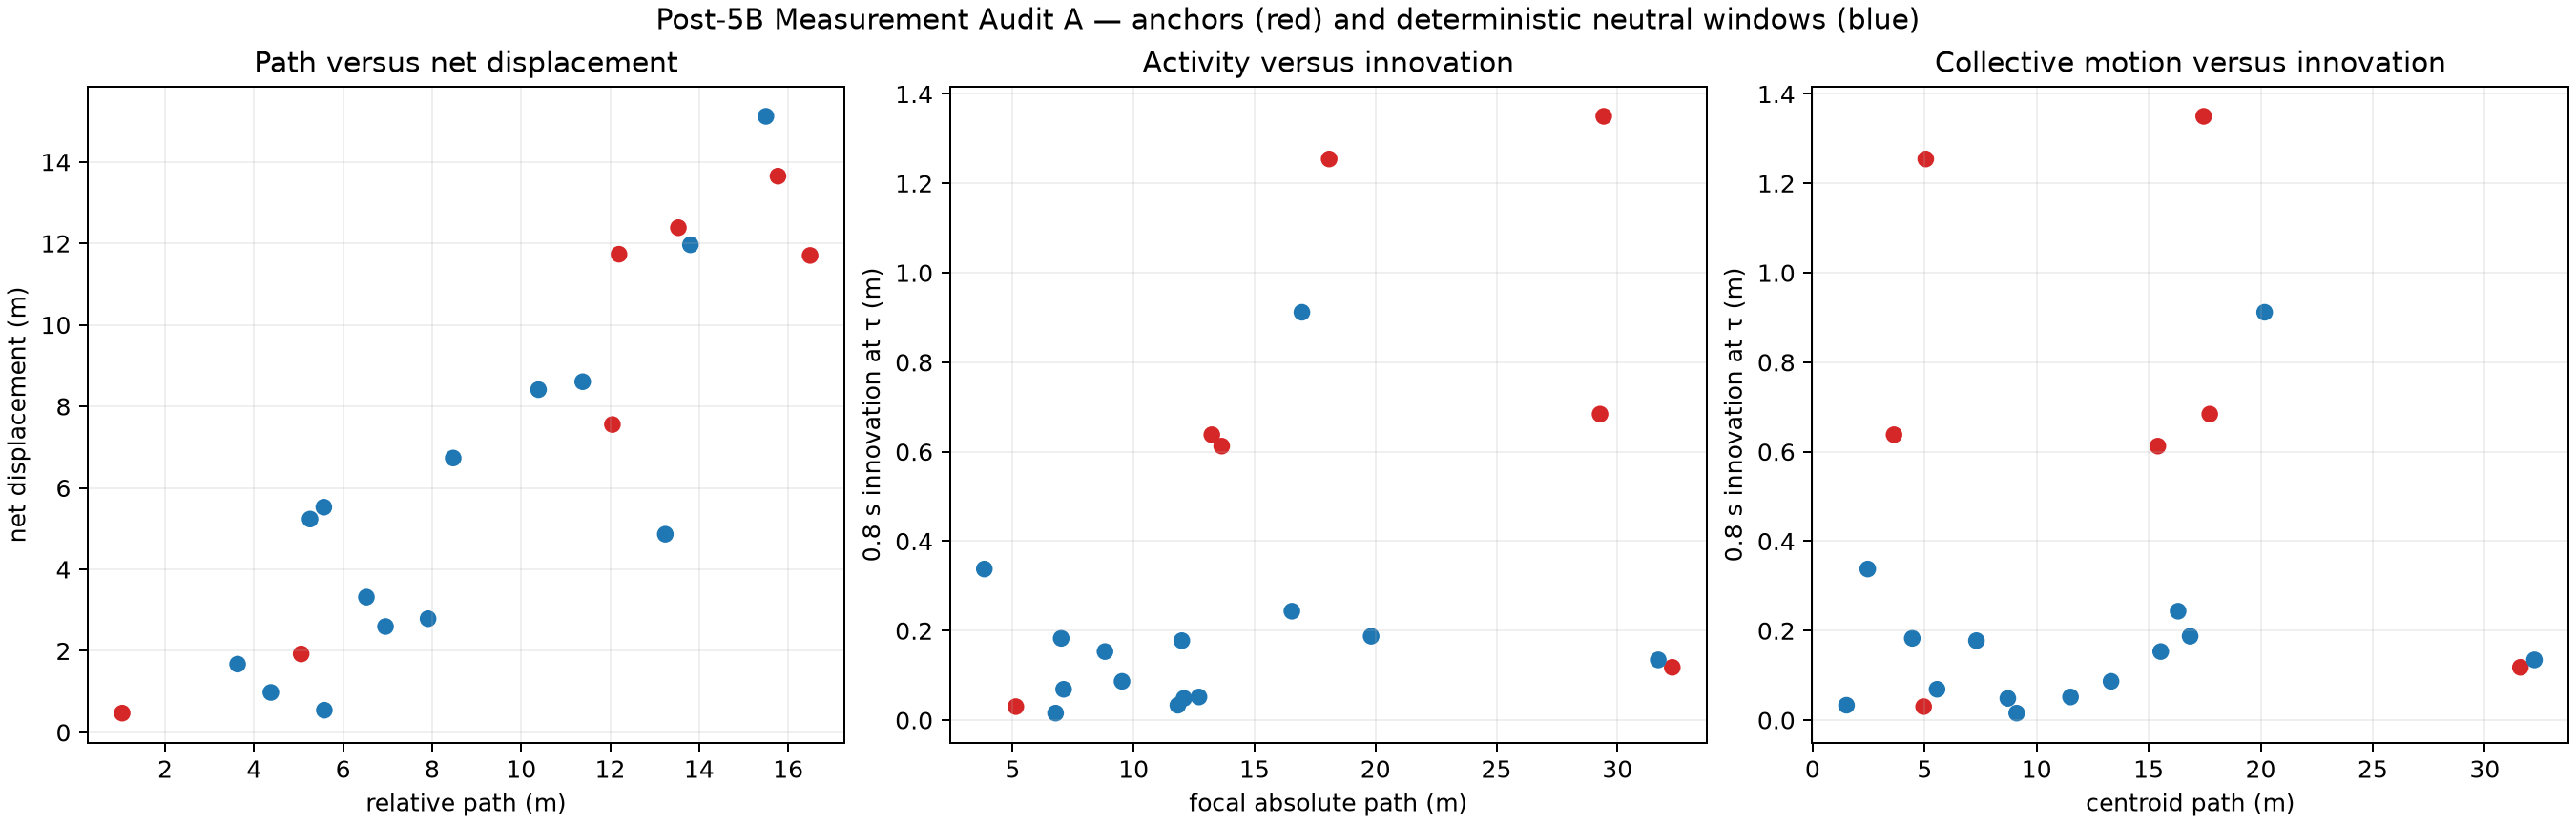

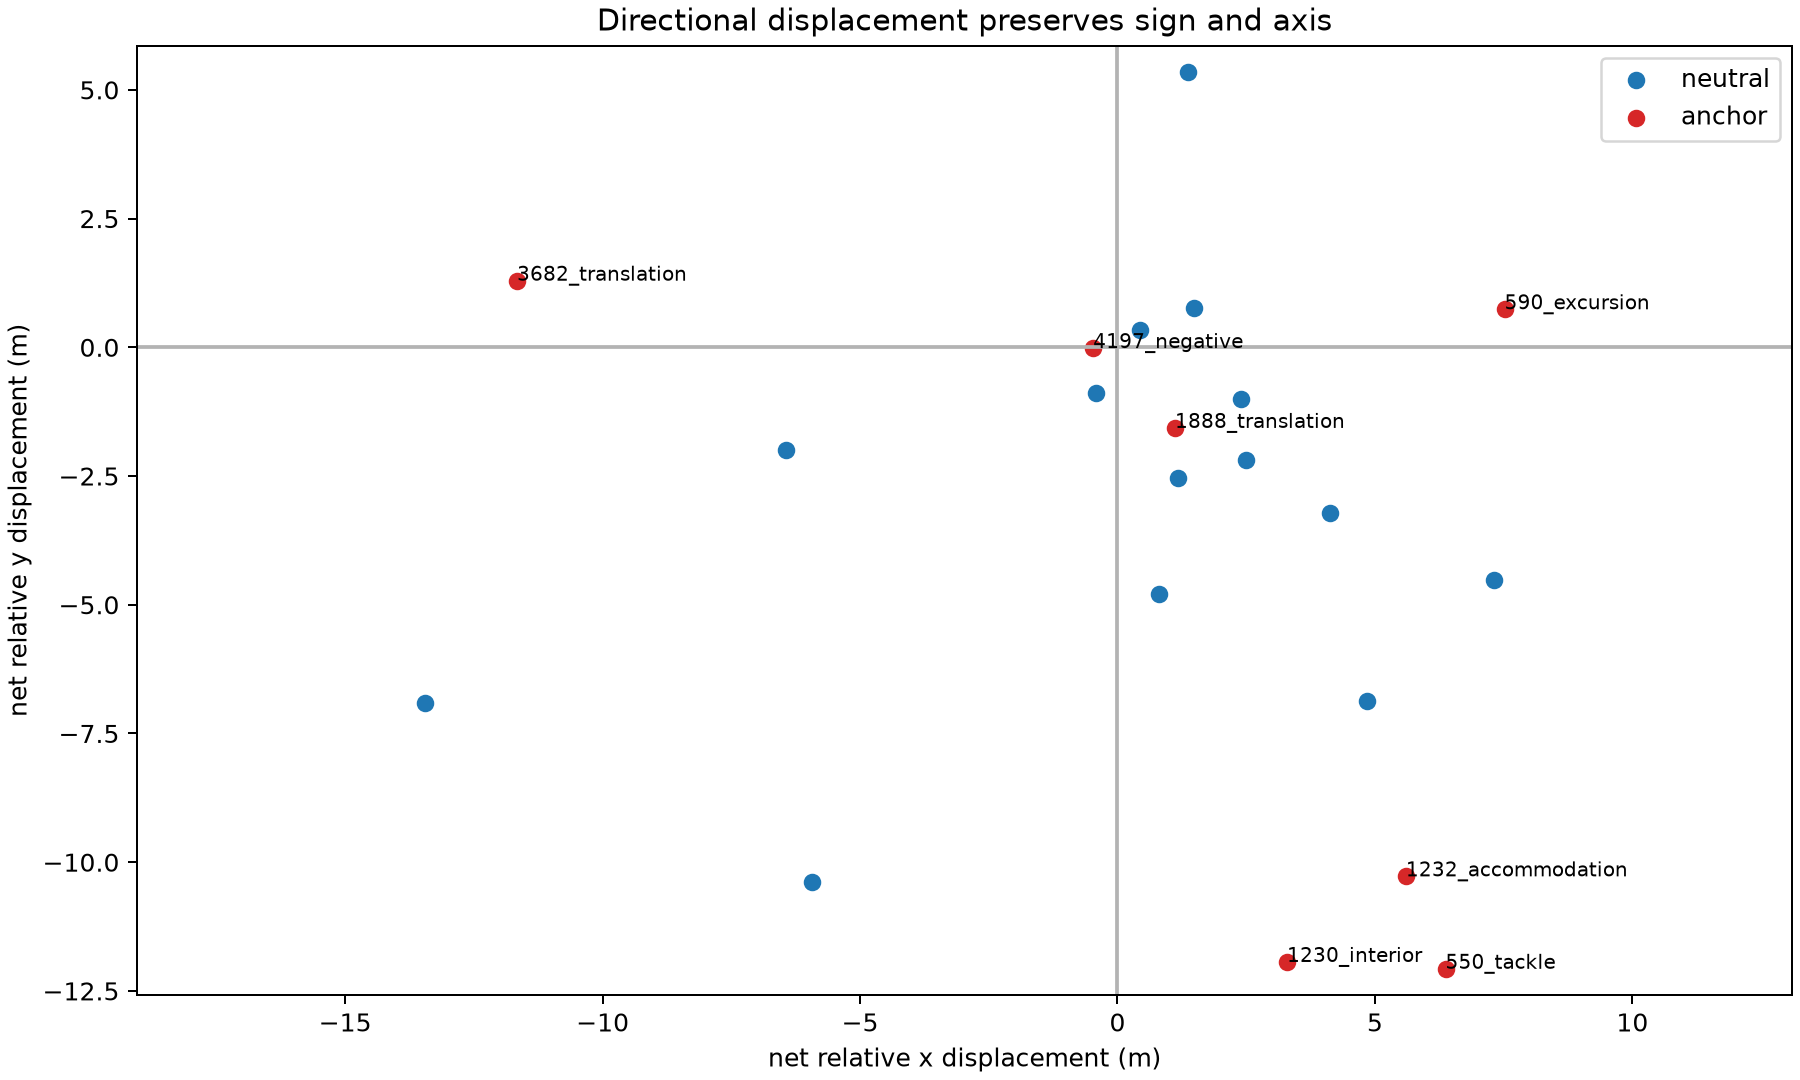

In [3]:
display(Image(filename=str(FIG/'anchor_neutral_summary.png')))
display(Image(filename=str(FIG/'directional_displacement_comparison.png')))

## Soccer-readable anchor diagnostics

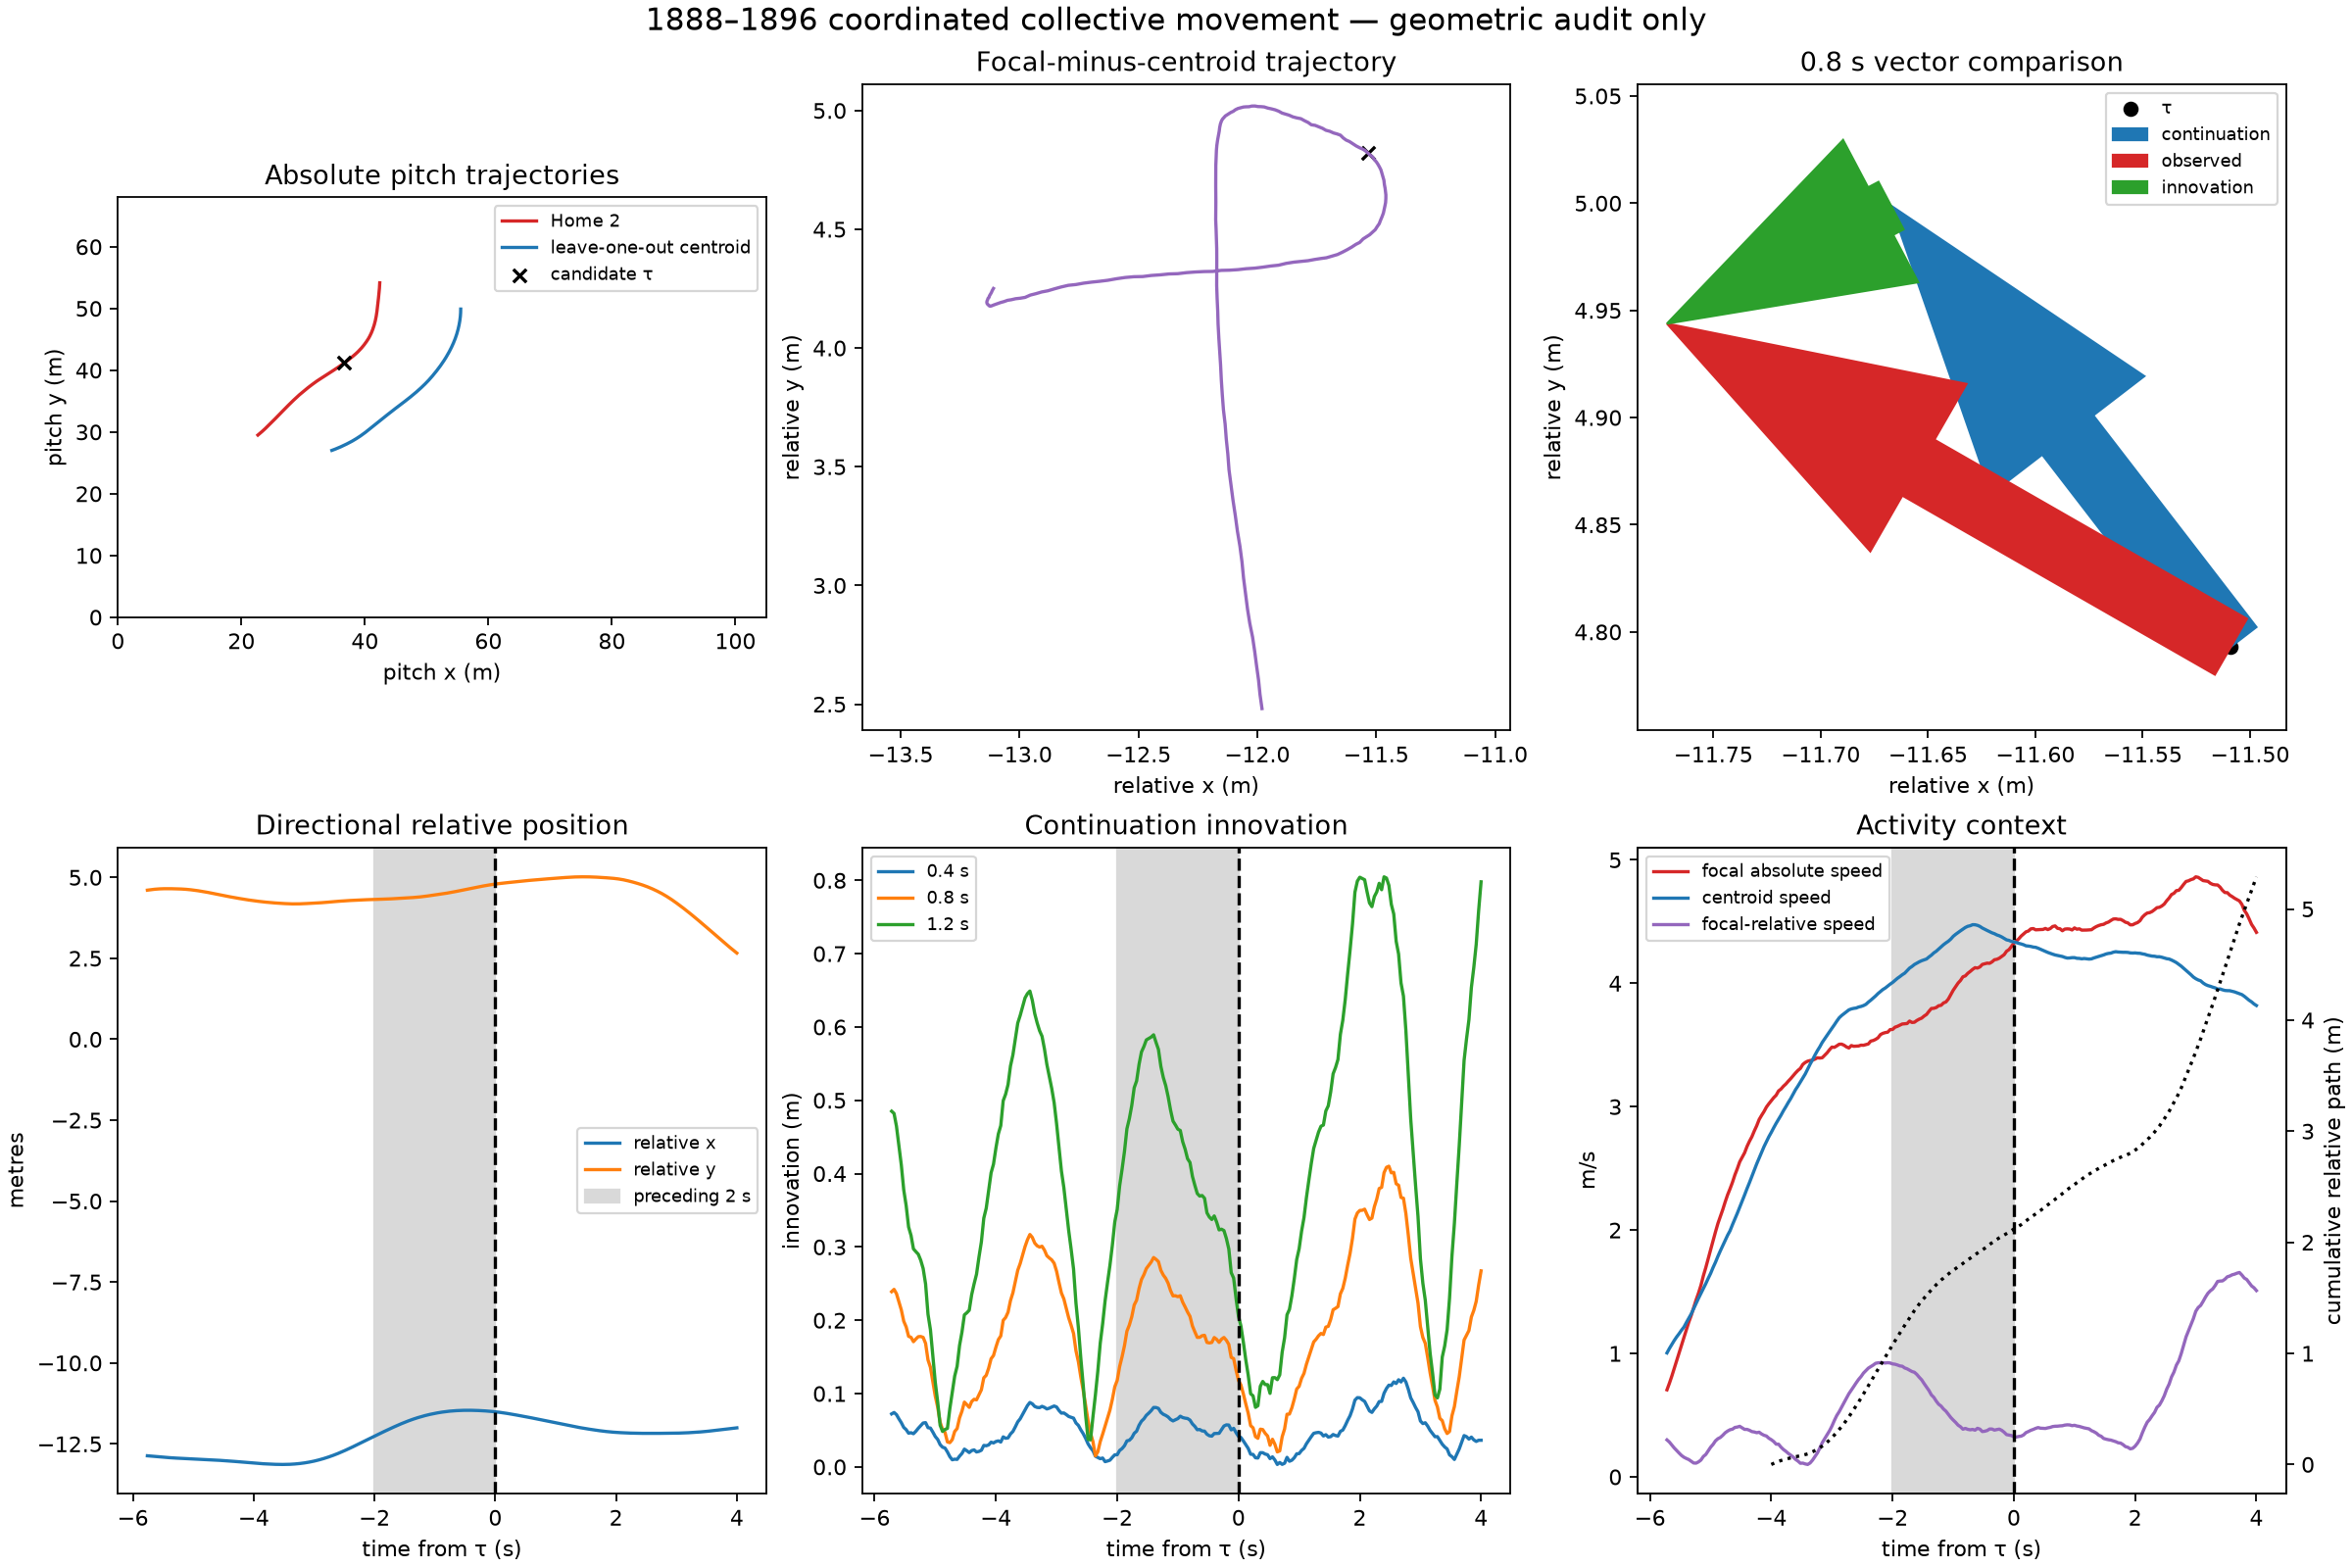

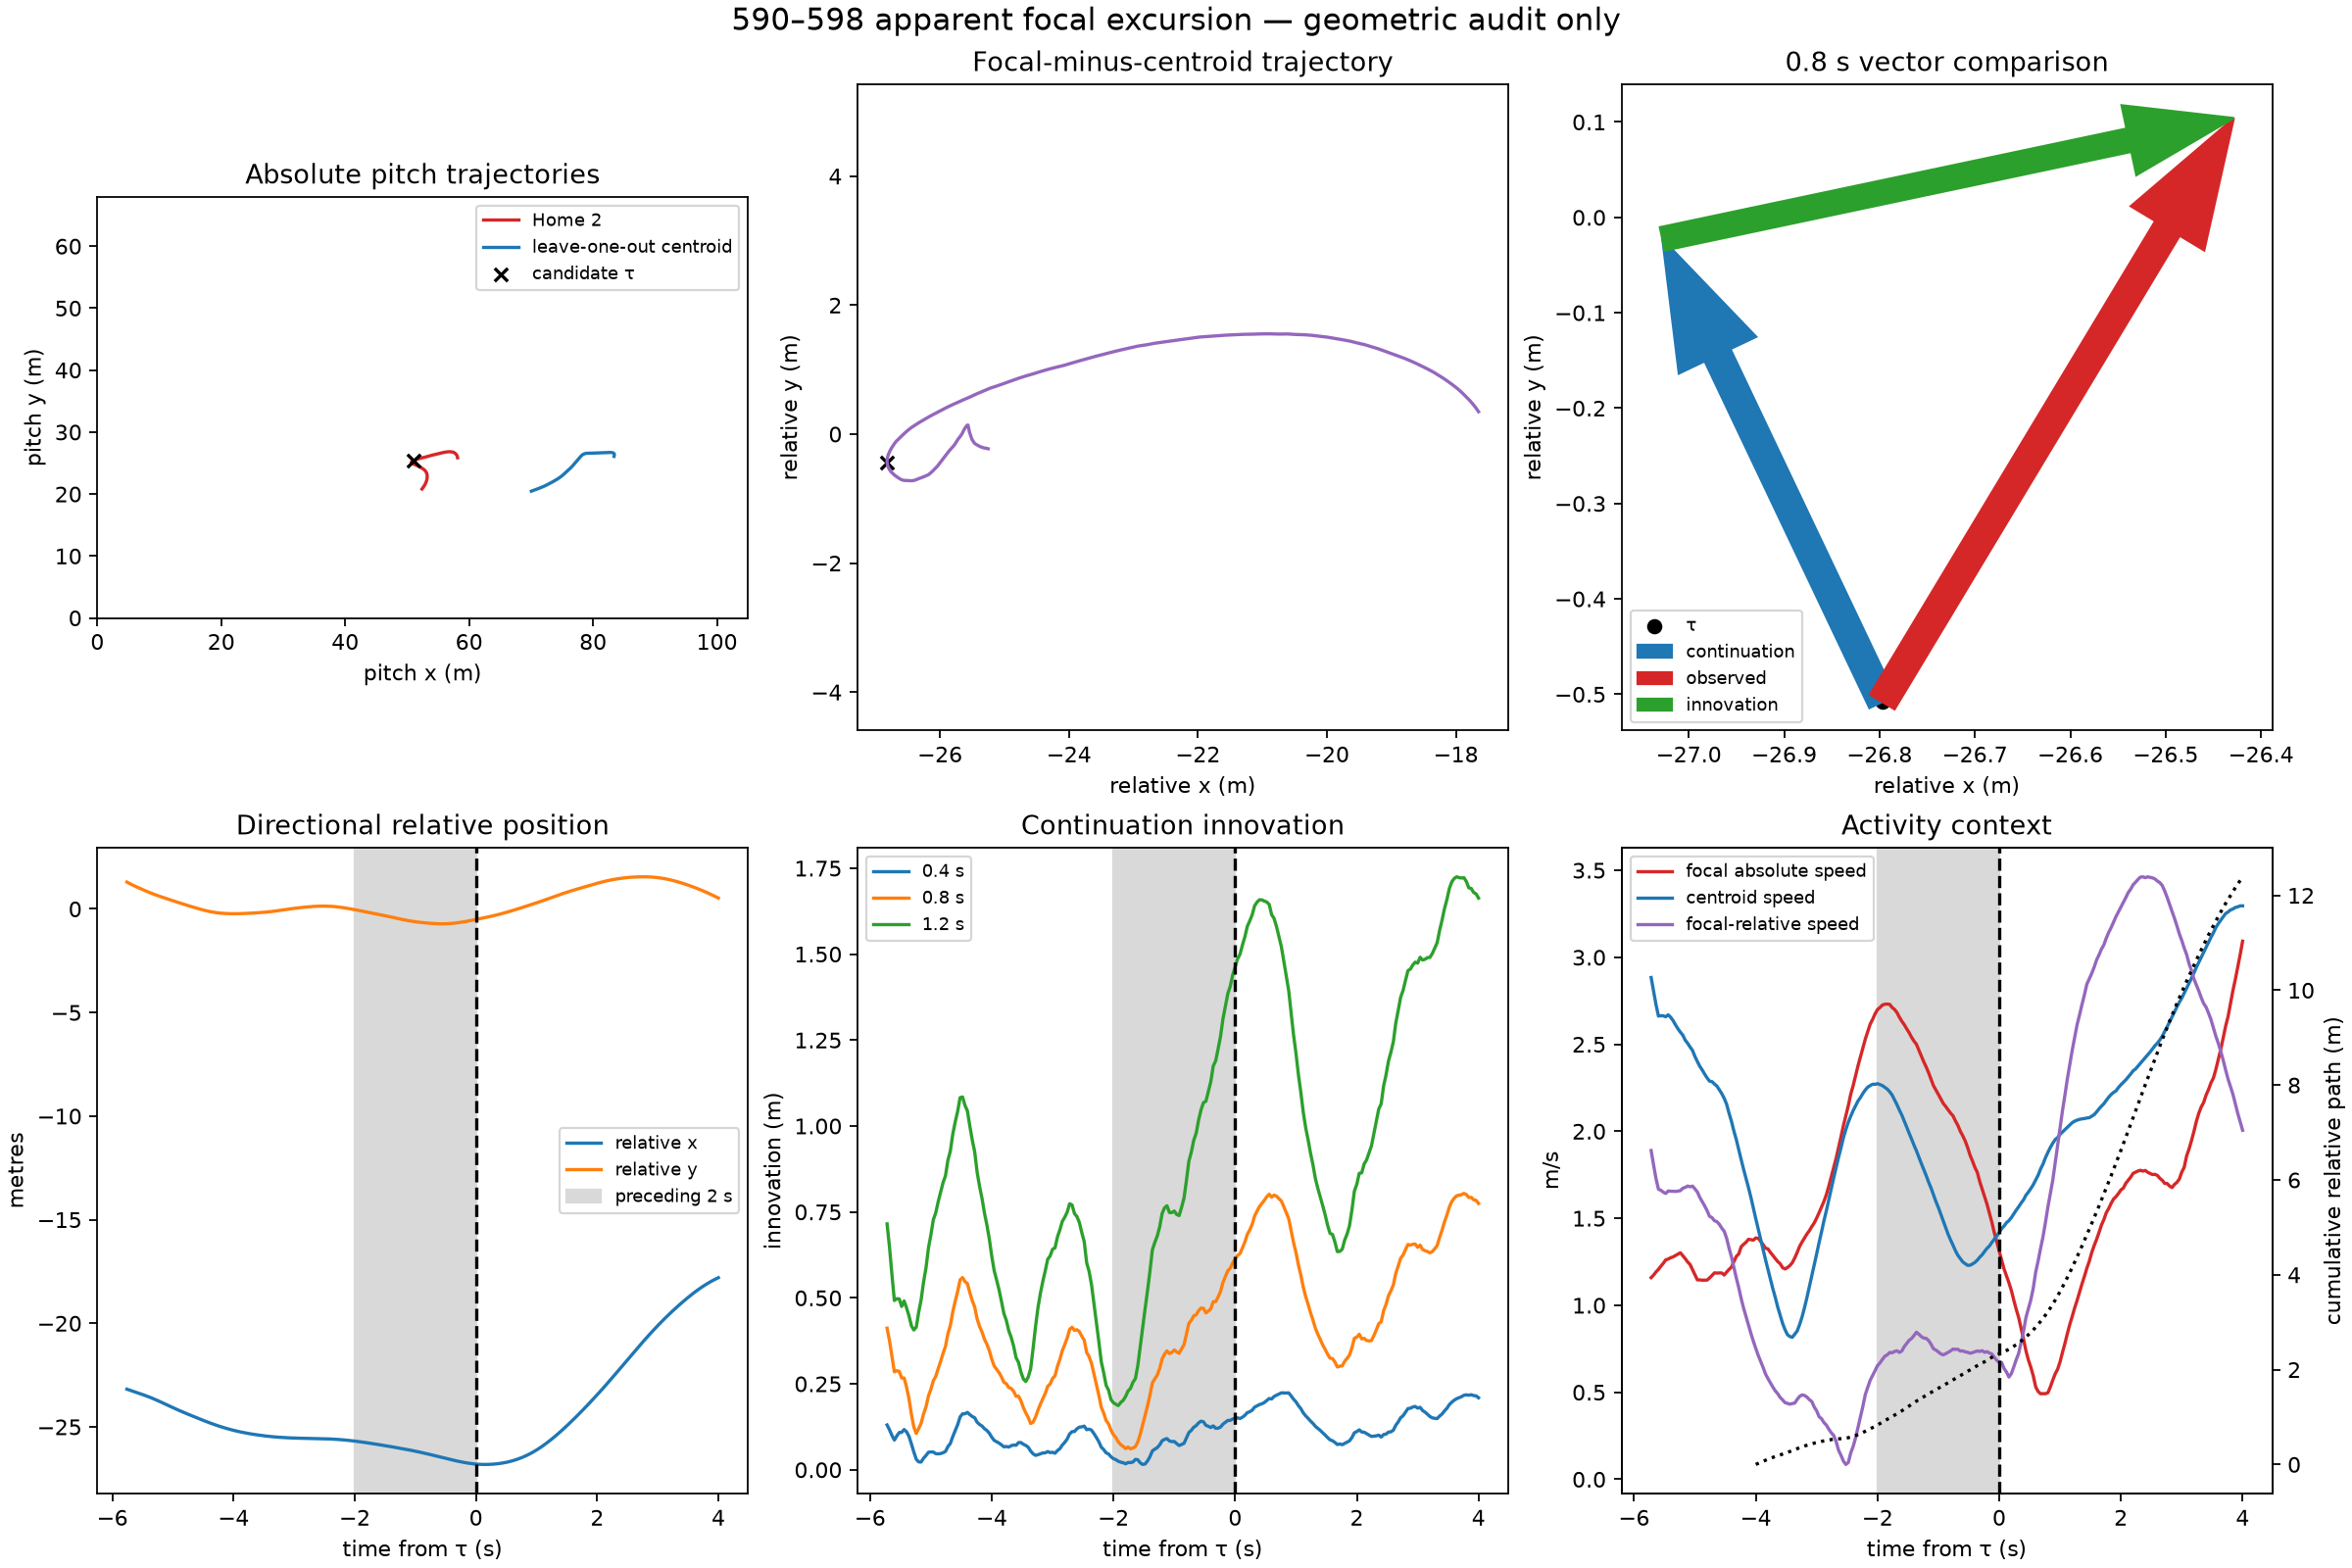

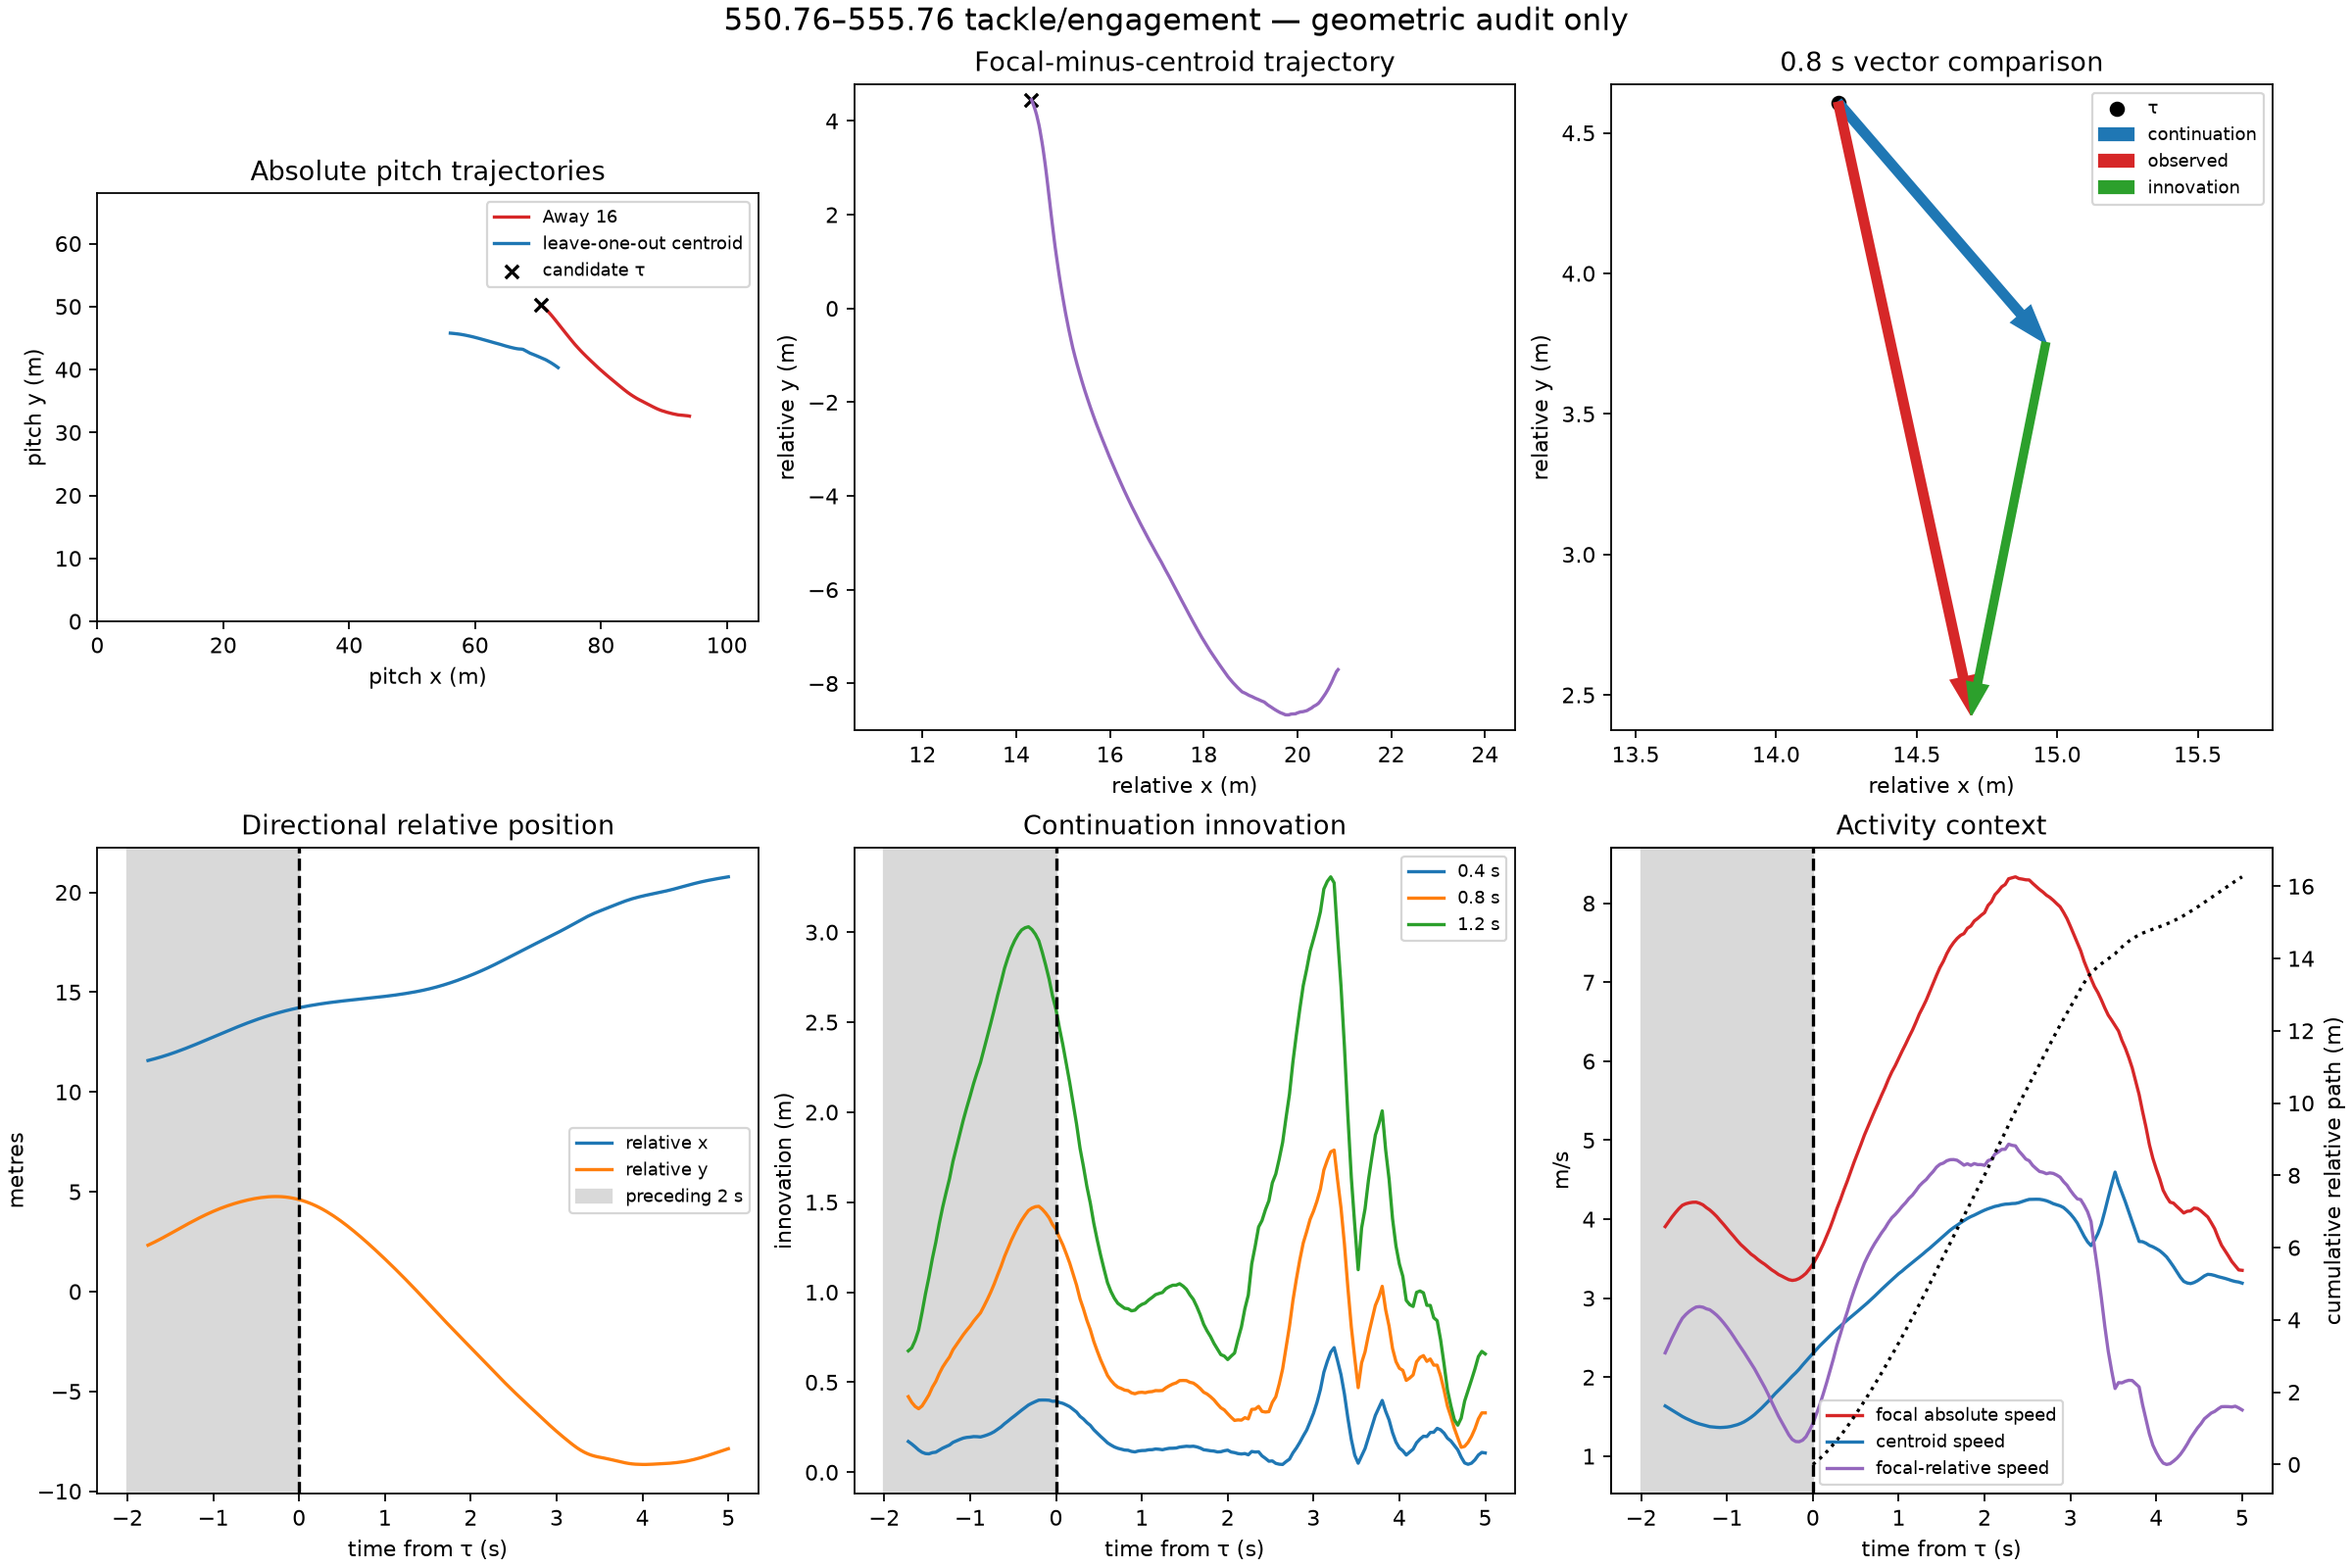

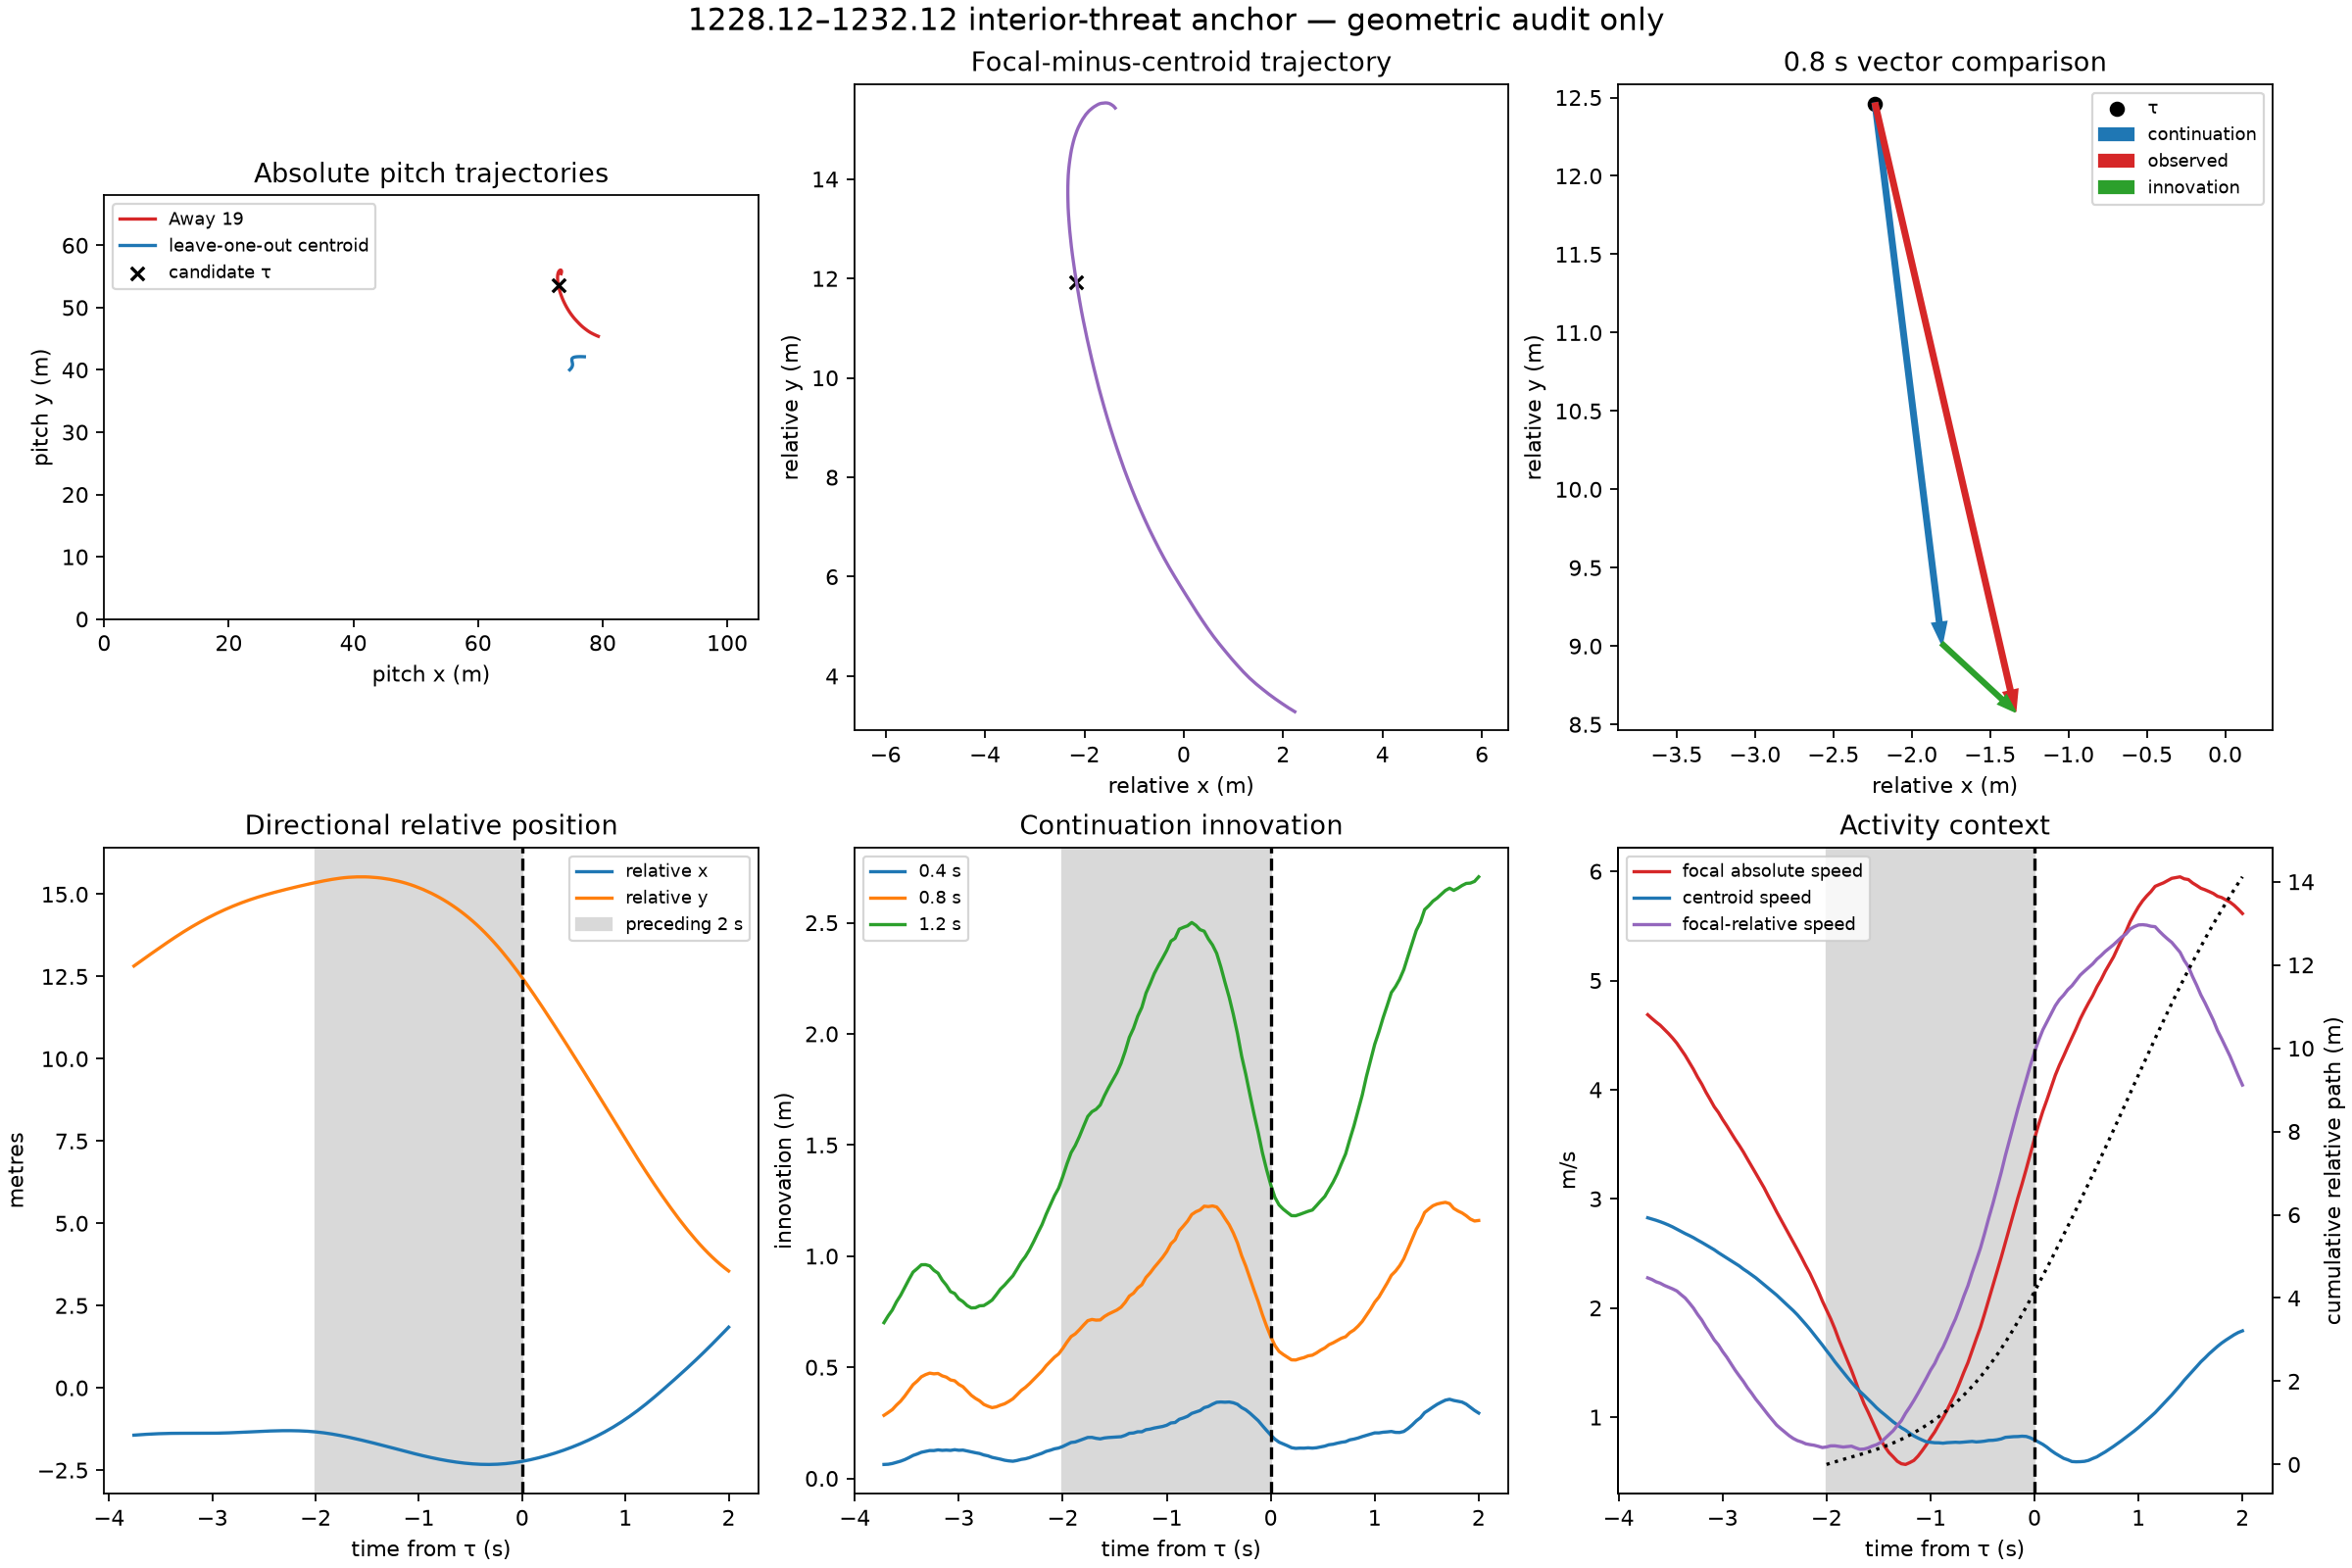

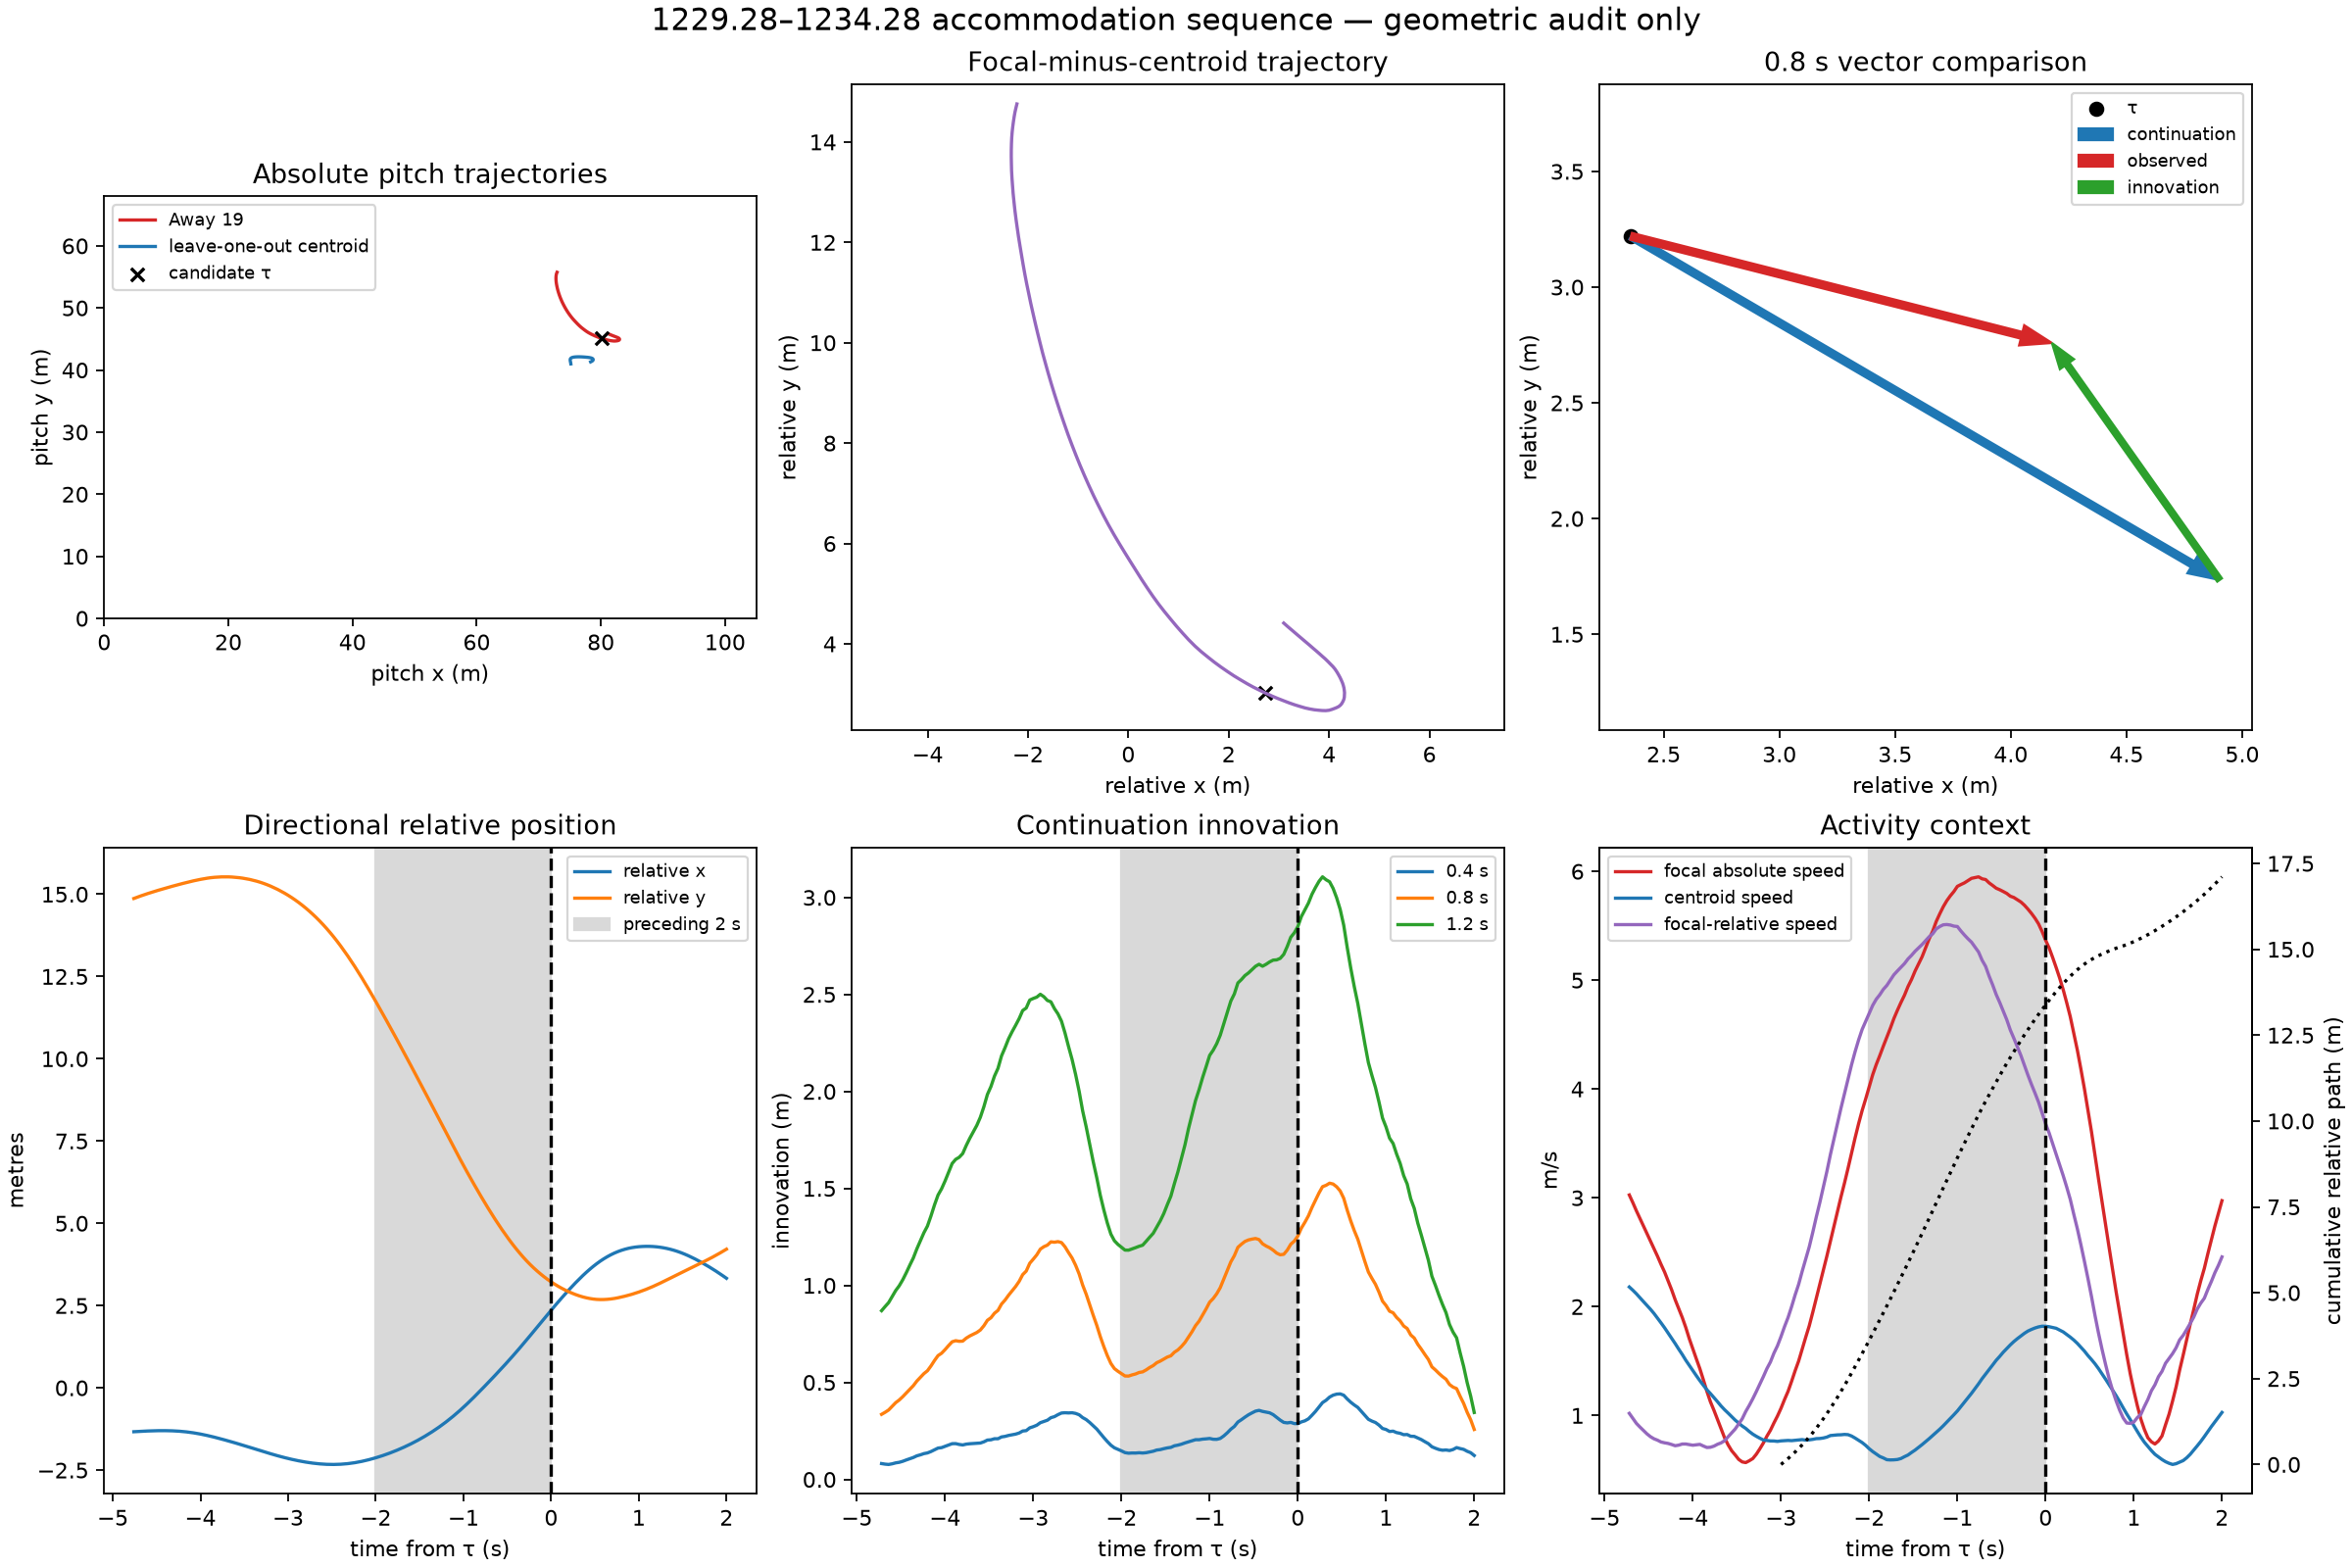

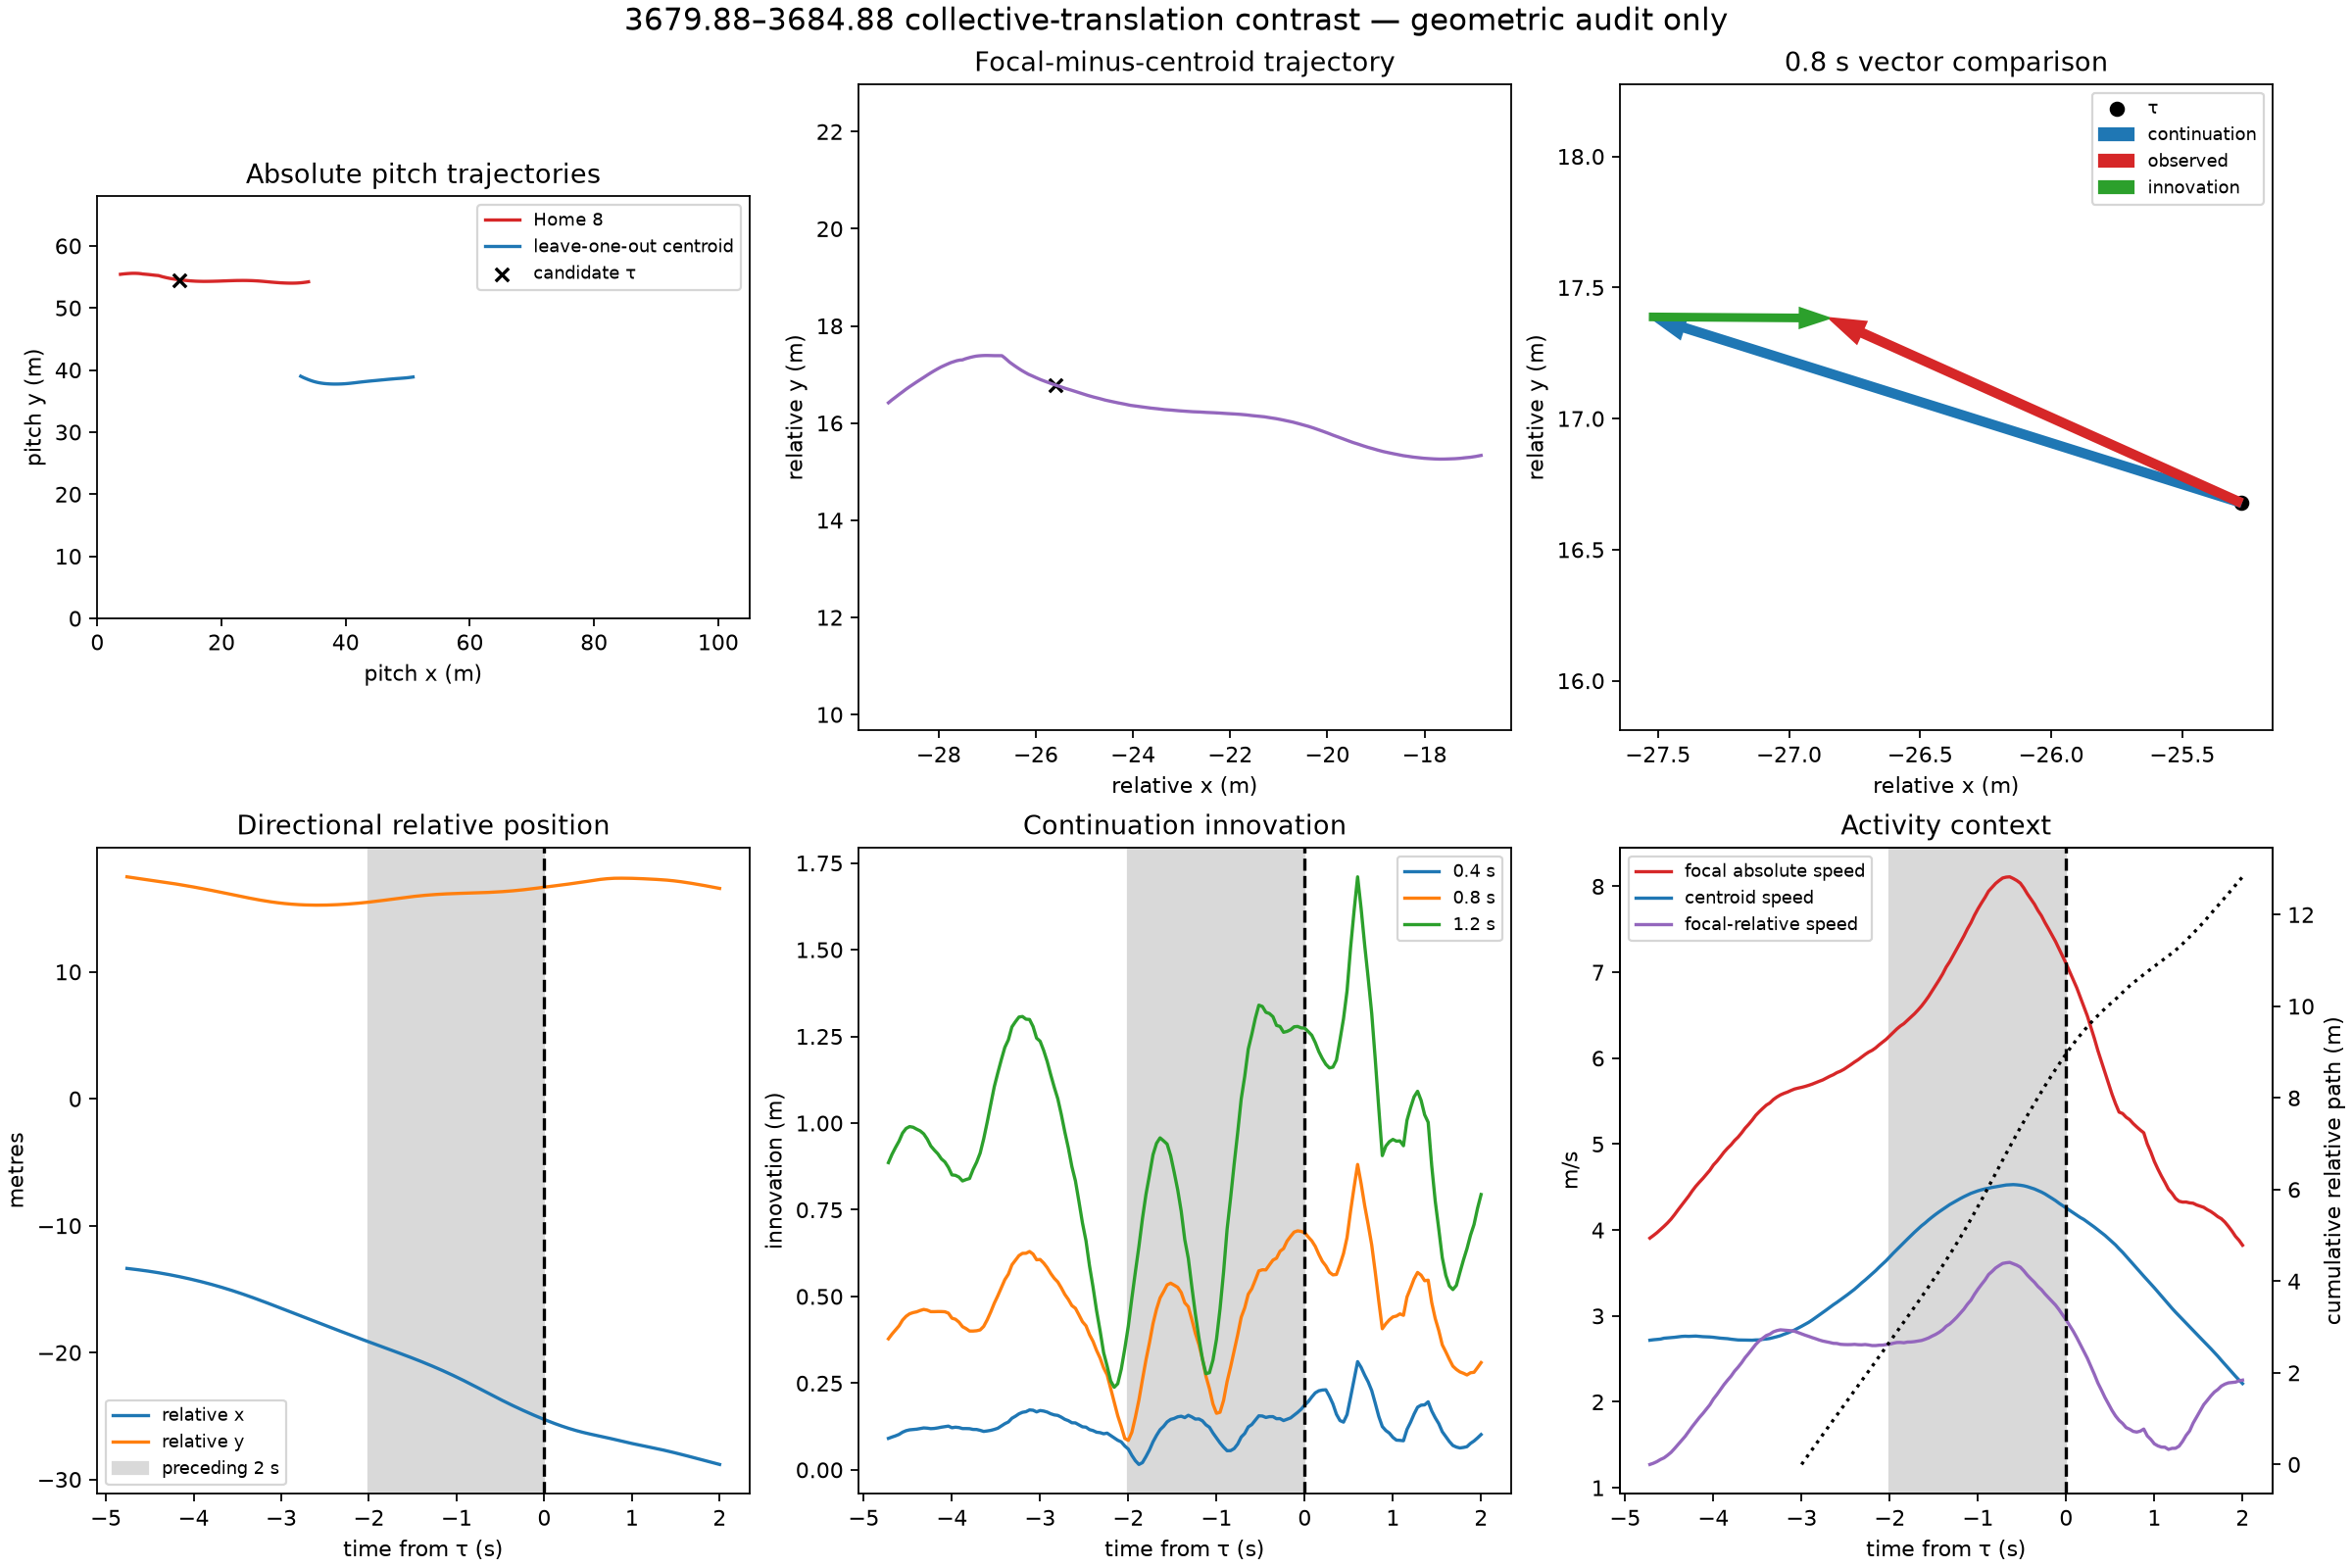

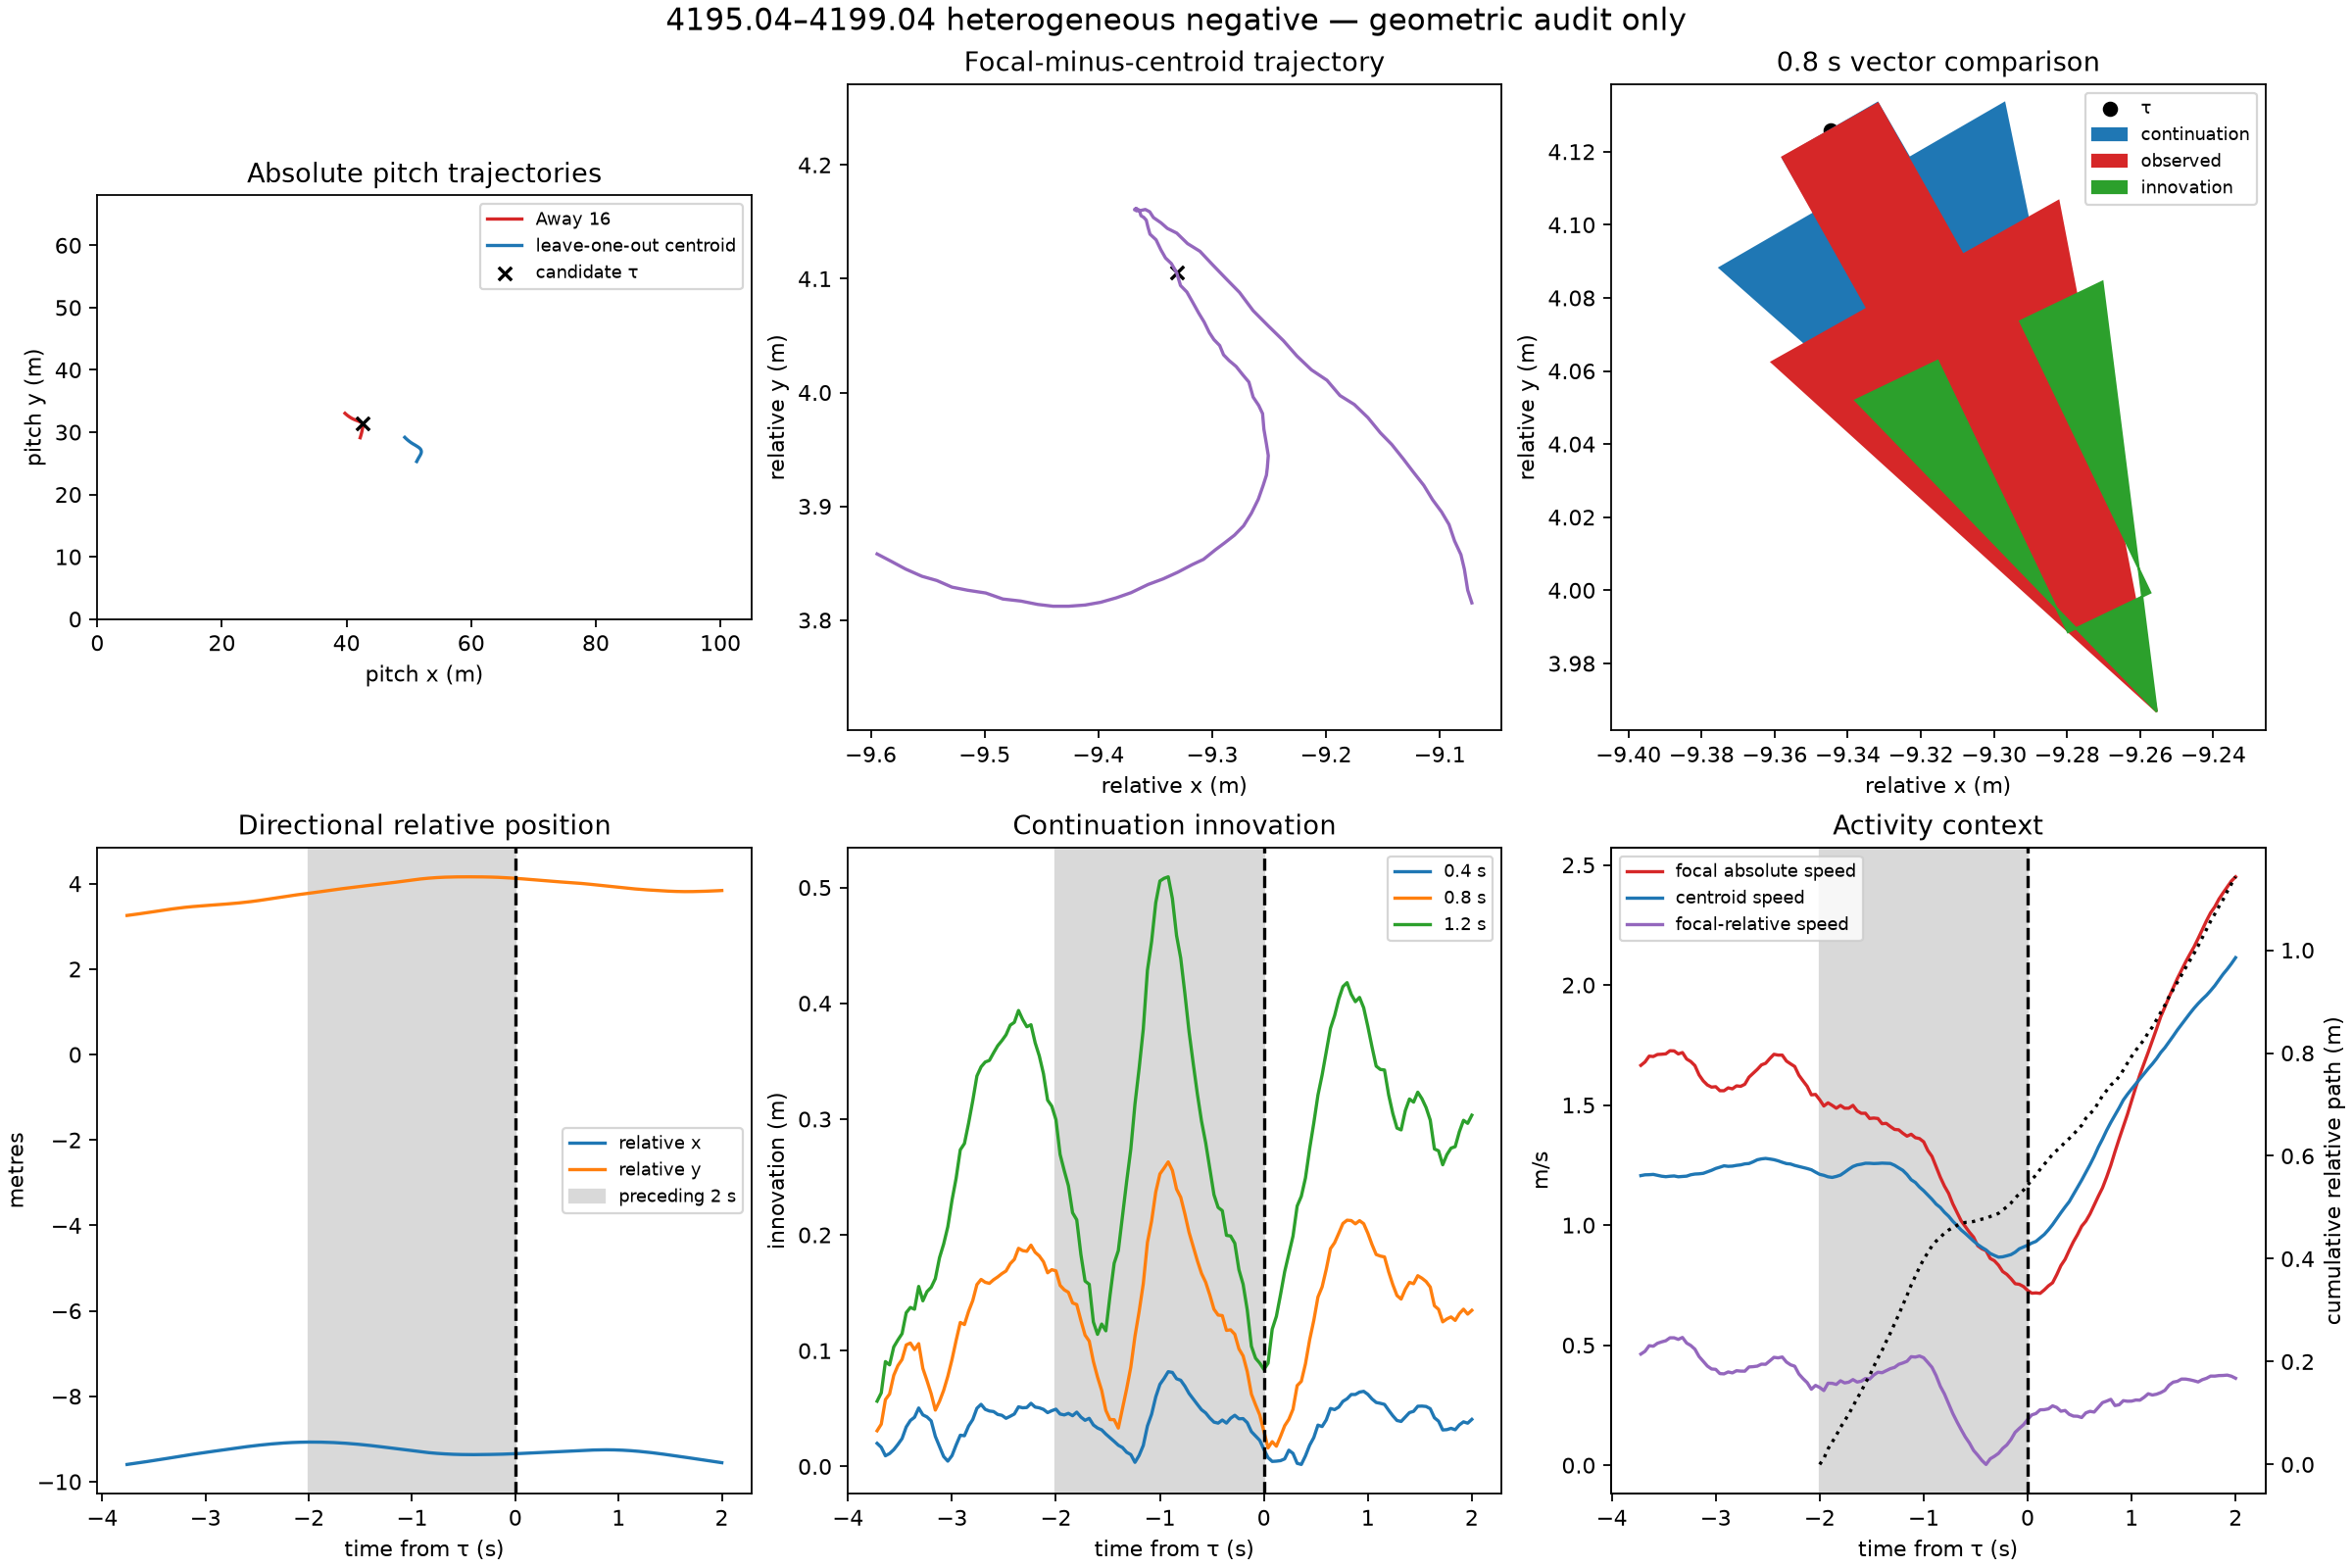

In [4]:
for name in ['1888_translation','590_excursion','550_tackle','1230_interior','1232_accommodation','3682_translation','4197_negative']:
    display(Image(filename=str(FIG/f'{name}.png')))

## Conclusion

**B — mixed.** Directional displacement usefully preserves sign and axis. Constant-velocity innovation is not identical to absolute or collective activity, but neutral overlap and pre-candidate movement prevent interpreting it as response onset. A formal validation phase is not yet justified.